# 01 — Data Augmentation
**Goal:** Expand the existing 5,000-clause binary dataset into a 3-class (Low / Medium / High) dataset enriched with real legal text from CUAD and UNFAIR-ToS, plus synthetic structured policy features.

| Source | What it is | Why it helps |
|---|---|---|
| `dataset-guidewire_sample.csv` | 5k synthetic insurance clauses | Base signal |
| UNFAIR-ToS (LexGLUE) | Real ToS sentences labeled as unfair/fair | Real-world risky legal language |
| CUAD | 510 commercial contracts, 41 clause types annotated | Real liability/indemnification clause text |
| Hedging injection | Low clauses with vague language added | Constructs Medium class |


In [ ]:
# ── Install dependencies ────────────────────────────────────────────────
!pip install datasets scikit-learn pandas numpy matplotlib seaborn -q

In [ ]:
# ── Imports ─────────────────────────────────────────────────────────────
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
print('Ready.')

Ready.


## 1. Load Existing Dataset

In [ ]:
# ── Load from Colab upload or local path ────────────────────────────────
try:
    from google.colab import files
    print('Running in Colab — upload dataset-guidewire_sample.csv')
    uploaded = files.upload()
    df_orig = pd.read_csv('dataset-guidewire_sample.csv')
except Exception:
    df_orig = pd.read_csv('../dataset-guidewire_sample.csv')

print(f'Loaded: {len(df_orig):,} rows')
print(df_orig['risk'].value_counts())
df_orig.head(3)

Running in Colab — upload dataset-guidewire_sample.csv


Saving dataset-guidewire_sample.csv to dataset-guidewire_sample.csv
Loaded: 5,000 rows
risk
Low     2500
High    2500
Name: count, dtype: int64


,clause,risk
0,Claims will be reviewed and paid when they com...,Low
1,Coverage may apply in certain situations subje...,High
2,Claims may be approved or declined based on th...,High


## 2. Relabel High → Medium / High Using LR Confidence

The existing dataset has only two classes. We use the LR confidence score to split the `High` class:
- LR confidence ≥ 0.75 → stays **High** (clear risk markers)
- LR confidence < 0.75 → becomes **Medium** (borderline, ambiguous)

In [ ]:
# ── Fit TF-IDF + LR on full existing dataset ────────────────────────────
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 3), sublinear_tf=True)
X_all = vectorizer.fit_transform(df_orig['clause'])

le = LabelEncoder()
y_all = le.fit_transform(df_orig['risk'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

lr = LogisticRegression(max_iter=2000, solver='lbfgs')
lr.fit(X_all, y_all)
print('LR trained.')

Label mapping: {'High': np.int64(0), 'Low': np.int64(1)}
LR trained.


In [ ]:
# ── Relabel ─────────────────────────────────────────────────────────────
MEDIUM_THRESHOLD = 0.75  # below this confidence → Medium

high_class_col = list(le.classes_).index('High')

df_relabeled = df_orig.copy()
high_mask = df_relabeled['risk'] == 'High'

X_high = vectorizer.transform(df_relabeled.loc[high_mask, 'clause'])
high_probs = lr.predict_proba(X_high)[:, high_class_col]

high_indices = df_relabeled.index[high_mask]
for i, idx in enumerate(high_indices):
    if high_probs[i] < MEDIUM_THRESHOLD:
        df_relabeled.loc[idx, 'risk'] = 'Medium'

df_relabeled['source'] = 'original_synthetic'
print('After relabeling:')
print(df_relabeled['risk'].value_counts())

After relabeling:
risk
Low     2500
High    2500
Name: count, dtype: int64


## 3. Load UNFAIR-ToS (LexGLUE)

Real sentences from Terms of Service documents, labeled by legal experts as fair or unfair across 8 categories. Unfair clause types map directly to insurance risk language patterns.

In [ ]:
# ── Load dataset and inspect structure ──────────────────────────────────
print('Loading UNFAIR-ToS from LexGLUE...')
tos_raw = load_dataset('lex_glue', 'unfair_tos') # Removed trust_remote_code=True
print('Done. Splits:', list(tos_raw.keys()))

# Inspect one example to understand the label format
sample = tos_raw['train'][0]
print('\nSample example:')
print('  text :', sample['text'][:120])
print('  label:', sample['labels'], '← type:', type(sample['labels']))

# Try to retrieve named labels
try:
    label_names = tos_raw['train'].features['labels'].feature.names
    print('  label names (multi-label):', label_names)
except Exception:
    try:
        label_names = tos_raw['train'].features['labels'].names
        print('  label names (single):', label_names)
    except Exception:
        label_names = ['O','CH','CR','LTD','TER','USE','PRP','LAW','JURIS']
        print('  using default label names:', label_names)

Loading UNFAIR-ToS from LexGLUE...
Done. Splits: ['train', 'test', 'validation']

Sample example:
  text : notice to california subscribers : you may cancel your subscription , without penalty or obligation , at any time prior 
  label: [] ← type: <class 'list'>
  label names (multi-label): ['Limitation of liability', 'Unilateral termination', 'Unilateral change', 'Content removal', 'Contract by using', 'Choice of law', 'Jurisdiction', 'Arbitration']


In [ ]:
# ── Risk mapping for UNFAIR-ToS labels ─────────────────────────────────
# O   = Other/OK         → Low
# CH  = Potentially harmful consumer clause → High
# CR  = Content removal  → Medium
# LTD = Limitation of liability → High
# TER = Unilateral termination  → High
# USE = Change of terms  → Medium
# PRP = Arbitration clause → Medium
# LAW = Choice of law    → Medium
# JURIS = Jurisdiction   → Low

UNFAIR_RISK_MAP_STR = {
    'O':    'Low',
    'CH':   'High',
    'CR':   'Medium',
    'LTD':  'High',
    'TER':  'High',
    'USE':  'Medium',
    'PRP':  'Medium',
    'LAW':  'Medium',
    'JURIS':'Low',
}
# Integer fallback (by position in label_names list)
UNFAIR_RISK_MAP_INT = {i: UNFAIR_RISK_MAP_STR.get(n, 'Medium')
                       for i, n in enumerate(label_names)}

def map_tos_label(label) -> str:
    """Handles multi-label list, single int, or string."""
    if isinstance(label, list):
        if not label:
            return 'Low'
        # Use highest-risk label if multiple
        risks = [map_tos_label(l) for l in label]
        priority = {'High': 0, 'Medium': 1, 'Low': 2}
        return min(risks, key=lambda r: priority[r])
    if isinstance(label, int):
        return UNFAIR_RISK_MAP_INT.get(label, 'Medium')
    return UNFAIR_RISK_MAP_STR.get(str(label), 'Medium')

# Test mapping
print('Test mappings:', {k: map_tos_label(k) for k in UNFAIR_RISK_MAP_STR})

Test mappings: {'O': 'Low', 'CH': 'High', 'CR': 'Medium', 'LTD': 'High', 'TER': 'High', 'USE': 'Medium', 'PRP': 'Medium', 'LAW': 'Medium', 'JURIS': 'Low'}


In [ ]:
# ── Extract UNFAIR-ToS clauses ──────────────────────────────────────────
MIN_LEN, MAX_LEN = 40, 600

tos_rows = []
for split in ['train', 'validation', 'test']:
    for ex in tos_raw[split]:
        text = ex['text'].strip()
        if not (MIN_LEN <= len(text) <= MAX_LEN):
            continue
        risk = map_tos_label(ex['labels'])
        tos_rows.append({'clause': text, 'risk': risk, 'source': 'unfair_tos'})

df_tos = pd.DataFrame(tos_rows)
print(f'UNFAIR-ToS: {len(df_tos):,} usable clauses')
print(df_tos['risk'].value_counts())
df_tos.sample(3)

UNFAIR-ToS: 8,925 usable clauses
risk
Low       7935
Medium     990
Name: count, dtype: int64


,clause,risk,source
6169,supercell may require that you accept updates ...,Low,unfair_tos
5832,you may not use the services for any illegal o...,Low,unfair_tos
286,"your continued use of the service now , or fol...",Medium,unfair_tos


## 4. Load CUAD — Contract Liability & Indemnification Clauses

CUAD is a QA dataset over 510 commercial contracts. Each example is a (contract, question, answer_span) triple. We extract answer spans for questions that relate to risk (liability caps, indemnification, limitation clauses) and ignore irrelevant questions (party names, effective dates).

In [ ]:
# ── Load CUAD ───────────────────────────────────────────────────────────
print('Loading CUAD (may take ~1 min)...')
try:
    # Attempt to load CUAD, but the current method is deprecated.
    # The 'datasets' library no longer supports dataset builder scripts for this dataset.
    # You will need to update this to a supported method,
    # likely by specifying data_files or using a specific revision.
    # Please consult the Hugging Face Hub for 'cuad' or 'theatticusproject/cuad-qa'
    # for the latest loading instructions.

    # Original attempts (commented out due to deprecation):
    # cuad_raw = load_dataset('cuad')
    # cuad_raw = load_dataset('theatticusproject/cuad-qa')

    raise RuntimeError("CUAD dataset loading failed: Dataset scripts are no longer supported.")

except RuntimeError as e:
    print(f"\n!!! ERROR: {e} !!!")
    print("Please manually update this cell to load CUAD using a supported method.")
    print("Refer to Hugging Face documentation for 'cuad' or 'theatticusproject/cuad-qa'.")
    # To prevent subsequent cells from crashing, we'll create an empty dummy dataset.
    # This will cause later steps that rely on CUAD data to have no data.
    # You MUST replace this with actual CUAD loading.
    cuad_raw = {'train': []} # Dummy dataset to allow program flow

print('Done. Splits:', list(cuad_raw.keys()))
print('Train size:', len(cuad_raw['train']))

# Inspect structure - this will now print based on the dummy cuad_raw or potentially fail
# if trying to access elements of an empty list, but the print statements are guarded.
if 'train' in cuad_raw and len(cuad_raw['train']) > 0:
    ex = cuad_raw['train'][0]
    print('\nFields:', list(ex.keys()))
    print('Question sample:', ex.get('question', ex.get('query', ''))[:80])
    print('Has answers:', bool(ex.get('answers', {}).get('text', [])))
else:
    print("\n(No CUAD examples loaded as a dummy dataset was created.)")

Loading CUAD (may take ~1 min)...

!!! ERROR: CUAD dataset loading failed: Dataset scripts are no longer supported. !!!
Please manually update this cell to load CUAD using a supported method.
Refer to Hugging Face documentation for 'cuad' or 'theatticusproject/cuad-qa'.
Done. Splits: ['train']
Train size: 0

(No CUAD examples loaded as a dummy dataset was created.)


In [ ]:
# ── CUAD question → risk mapping ────────────────────────────────────────
CUAD_RISK_MAP = {
    # High risk — limits payout, assigns blame, waives rights
    'cap on liability':           'High',
    'limitation on liability':    'High',
    'uncapped liability':         'High',
    'liquidated damages':         'High',
    'indemnification':            'High',
    'non-disparagement':          'High',
    'covenant not to sue':        'High',
    # Medium risk — conditional, transferable, or changeable terms
    'insurance':                  'Medium',
    'warranty duration':          'Medium',
    'ip ownership assignment':    'Medium',
    'change of control':          'Medium',
    'anti-assignment':            'Medium',
    'audit rights':               'Medium',
    'termination for convenience':'Medium',
    'renewal term':               'Medium',
    'most favored nation':        'Medium',
    # Low risk — administrative, definitional
    'governing law':              'Low',
    'effective date':             'Low',
    'expiration date':            'Low',
    'agreement date':             'Low',
    'notice period':              'Low',
}

def get_cuad_risk(question: str):
    q = question.lower()
    for key, risk in CUAD_RISK_MAP.items():
        if key in q:
            return risk
    return None  # skip questions not in our map

print('Mapping defined for', len(CUAD_RISK_MAP), 'clause types.')

Mapping defined for 21 clause types.


In [ ]:
import pandas as pd
import re

MIN_LEN, MAX_LEN = 20, 700   # thoda relaxed rakha hai
seen = set()
cuad_rows = []

def get_cuad_risk(question):
    q = question.lower()

    # High risk clauses
    if any(word in q for word in ["liability", "indemn", "indemnification", "breach", "penalty"]):
        return "High"

    # Low risk clauses
    elif any(word in q for word in ["payment", "termination", "notice", "duration"]):
        return "Low"

    return None

# Detect correct question field
if hasattr(cuad_raw['train'], 'column_names'):
    question_field = 'question' if 'question' in cuad_raw['train'].column_names else 'query'
else:
    question_field = 'question'

for split in cuad_raw.keys():
    for ex in cuad_raw[split]:

        question = ex.get(question_field, "")
        risk = get_cuad_risk(question)

        if risk is None:
            continue

        answers = ex.get("answers", {})
        texts = answers.get("text", [])

        if not texts:
            continue

        clause = texts[0].strip()

        # First sentence only
        first_sentence = re.split(r'(?<=[.!?])\s+', clause)[0]

        if not (MIN_LEN <= len(first_sentence) <= MAX_LEN):
            continue

        if first_sentence in seen:
            continue

        seen.add(first_sentence)

        cuad_rows.append({
            "clause": first_sentence,
            "risk": risk,
            "source": "cuad"
        })

# Create dataframe
df_cuad = pd.DataFrame(cuad_rows)

# ✅ Safe printing
print(f"CUAD: {len(df_cuad)} clauses extracted")

if not df_cuad.empty:
    print(df_cuad['risk'].value_counts())
    display(df_cuad.sample(3))
else:
    print("⚠️ No data extracted — check mapping")

CUAD: 0 clauses extracted
⚠️ No data extracted — check mapping


## 5. Generate Medium Clauses via Hedging Injection

Medium-risk clauses linguistically sit between clear (Low) and clearly risky (High). We construct them by:
1. Taking Low clauses from the original dataset
2. Replacing definitive verbs (`will`, `shall`) with conditional ones (`may`)
3. Appending a hedging phrase (insurer-discretion or conditional language)

In [ ]:
HEDGES = [
    ', subject to review by the insurer',
    ', depending on the circumstances at the time of the claim',
    ', if conditions are deemed satisfactory by the insurer',
    ', at the insurer\'s reasonable discretion',
    ', provided that internal evaluation supports the claim',
    ', subject to applicable policy limitations and review',
    ', contingent on documentation review',
    ', depending on availability of supporting evidence',
    ', subject to the insurer\'s assessment of the circumstances',
    ', if coverage criteria are met per internal guidelines',
]

def inject_hedge(clause: str) -> str:
    clause = clause.rstrip('.')
    clause = re.sub(r'\bwill\b', 'may', clause)
    clause = re.sub(r'\bshall\b', 'may', clause)
    clause = re.sub(r'\bmust\b', 'should', clause)
    return clause + random.choice(HEDGES) + '.'

# Sample from the Low portion of the relabeled dataset
low_pool = df_relabeled[df_relabeled['risk'] == 'Low']['clause'].tolist()
n_medium_to_generate = 1500
sample_pool = random.sample(low_pool, min(n_medium_to_generate, len(low_pool)))

hedged_rows = [{'clause': inject_hedge(c), 'risk': 'Medium', 'source': 'hedged_synthetic'}
               for c in sample_pool]
df_hedged = pd.DataFrame(hedged_rows)

print(f'Generated {len(df_hedged):,} hedged Medium clauses')
print('\nSamples:')
for r in df_hedged.head(3).itertuples():
    print(' -', r.clause)

Generated 1,500 hedged Medium clauses

Samples:
 - Payment for losses may be issued after verification of the insured event and policy compliance. subject to review, contingent on documentation review.
 - Claims may be reviewed and paid when they comply with the conditions specified in this policy, contingent on documentation review.
 - The insurer may compensate the insured subject to verification of eligibility criteria. after internal evaluation, depending on availability of supporting evidence.


## 6. Combine All Sources

In [ ]:
dataframes_to_concat = [
    df_relabeled[['clause', 'risk', 'source']],
    df_tos[['clause', 'risk', 'source']],
    df_hedged[['clause', 'risk', 'source']],
]

# Only include df_cuad if it's not empty, otherwise selecting columns will cause a KeyError
if not df_cuad.empty:
    dataframes_to_concat.append(df_cuad[['clause', 'risk', 'source']])

df_combined = pd.concat(dataframes_to_concat, ignore_index=True)

# Drop any blanks
df_combined = df_combined[df_combined['clause'].str.strip().str.len() > 20].reset_index(drop=True)

print(f'Combined: {len(df_combined):,} rows')
print('\nBy risk:')
print(df_combined['risk'].value_counts())
print('\nBy source × risk:')
print(df_combined.groupby(['source', 'risk']).size().unstack(fill_value=0))

Combined: 15,425 rows

By risk:
risk
Low       10435
High       2500
Medium     2490
Name: count, dtype: int64

By source × risk:
risk                High   Low  Medium
source                                
hedged_synthetic       0     0    1500
original_synthetic  2500  2500       0
unfair_tos             0  7935     990


## 7. Add Synthetic Structured Features

These are synthetically generated but with **actuarially realistic distributions**:
- Higher-risk labels get higher prior claims counts and larger coverage amounts (reflects real underwriting correlation)
- Policy type is randomly sampled with realistic market share weights
- Coverage amounts follow log-normal distributions (industry standard assumption)

In [ ]:
POLICY_PROFILES = {
    'auto':       {'cov_range': (25_000,   150_000),   'claims_lambda': 1.2},
    'home':       {'cov_range': (100_000,  750_000),   'claims_lambda': 0.4},
    'commercial': {'cov_range': (500_000,  5_000_000), 'claims_lambda': 0.8},
    'life':       {'cov_range': (100_000,  2_000_000), 'claims_lambda': 0.1},
}
# Market share weights: auto and home are most common
POLICY_WEIGHTS = [0.35, 0.35, 0.20, 0.10]

# Risk shifts coverage amount and claim frequency upward
RISK_BIAS = {
    'Low':    {'cov_pct': 0.30, 'claims_mult': 0.5},
    'Medium': {'cov_pct': 0.55, 'claims_mult': 1.0},
    'High':   {'cov_pct': 0.75, 'claims_mult': 1.8},
}

def generate_structured(risk_label: str, n: int) -> pd.DataFrame:
    bias = RISK_BIAS[risk_label]
    policy_types = np.random.choice(list(POLICY_PROFILES.keys()), n, p=POLICY_WEIGHTS)
    rows = []
    for pt in policy_types:
        p = POLICY_PROFILES[pt]
        lo, hi = p['cov_range']
        target = lo + (hi - lo) * bias['cov_pct']
        coverage = int(np.clip(np.random.lognormal(np.log(target), 0.4), lo, hi))
        claims = int(np.random.poisson(p['claims_lambda'] * bias['claims_mult']))
        rows.append({
            'policy_type':       pt,
            'coverage_amount':   coverage,
            'applicant_age':     int(np.random.randint(18, 76)),
            'prior_claims_count':min(claims, 5),
            'deductible_amount': int(np.random.choice([500, 1000, 2500, 5000])),
            'state':             np.random.choice(['TX','CA','NY','FL','IL','OH','PA','GA']),
        })
    return pd.DataFrame(rows)

# Generate structured features per risk class and align with df_combined
# Sort combined by risk so we can concat structured blocks cleanly
df_sorted = df_combined.sort_values('risk').reset_index(drop=True)

struct_parts = []
for risk in ['High', 'Low', 'Medium']:  # alphabetical (sort order)
    n = (df_sorted['risk'] == risk).sum()
    struct_parts.append(generate_structured(risk, n))

df_struct = pd.concat(struct_parts, ignore_index=True)

df_final = pd.concat([df_sorted, df_struct], axis=1)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

print('Final shape:', df_final.shape)
print(df_final['risk'].value_counts())
df_final.head(4)

Final shape: (15425, 9)
risk
Low       10435
High       2500
Medium     2490
Name: count, dtype: int64


,clause,risk,source,policy_type,coverage_amount,applicant_age,prior_claims_count,deductible_amount,state
0,Benefits may be granted depending on circumsta...,High,original_synthetic,home,363869,63,1,500,IL
1,The insurer shall compensate the insured subje...,Low,original_synthetic,auto,35313,49,0,1000,OH
2,"by way of example , and not as a limitation , ...",Low,unfair_tos,auto,69999,30,0,500,NY
3,The insurer shall generally compensate valid c...,Low,original_synthetic,home,253127,52,0,5000,TX


## 8. Validate

In [ ]:
print('=== Dataset Validation ===')
print(f'Total rows       : {len(df_final):,}')
print(f'Missing clauses  : {df_final["clause"].isna().sum()}')
print(f'Missing labels   : {df_final["risk"].isna().sum()}')
print(f'Duplicate clauses: {df_final["clause"].duplicated().sum()}')
print()
print('Clause length stats (chars):')
print(df_final['clause'].str.len().describe().round(1))
print()
print('Coverage amount by risk:')
print(df_final.groupby('risk')['coverage_amount'].describe()[['mean','min','max']].round(0))
print()
print('Avg prior claims by risk:')
print(df_final.groupby('risk')['prior_claims_count'].mean().round(2))

=== Dataset Validation ===
Total rows       : 15,425
Missing clauses  : 0
Missing labels   : 0
Duplicate clauses: 5863

Clause length stats (chars):
count    15425.0
mean       152.2
std         84.6
min         40.0
25%        100.0
50%        126.0
75%        177.0
max        600.0
Name: clause, dtype: float64

Coverage amount by risk:
             mean      min        max
risk                                 
High    1220769.0  35502.0  5000000.0
Low      602865.0  25000.0  5000000.0
Medium   953662.0  25580.0  5000000.0

Avg prior claims by risk:
risk
High      1.31
Low       0.36
Medium    0.73
Name: prior_claims_count, dtype: float64


## 9. Visualize

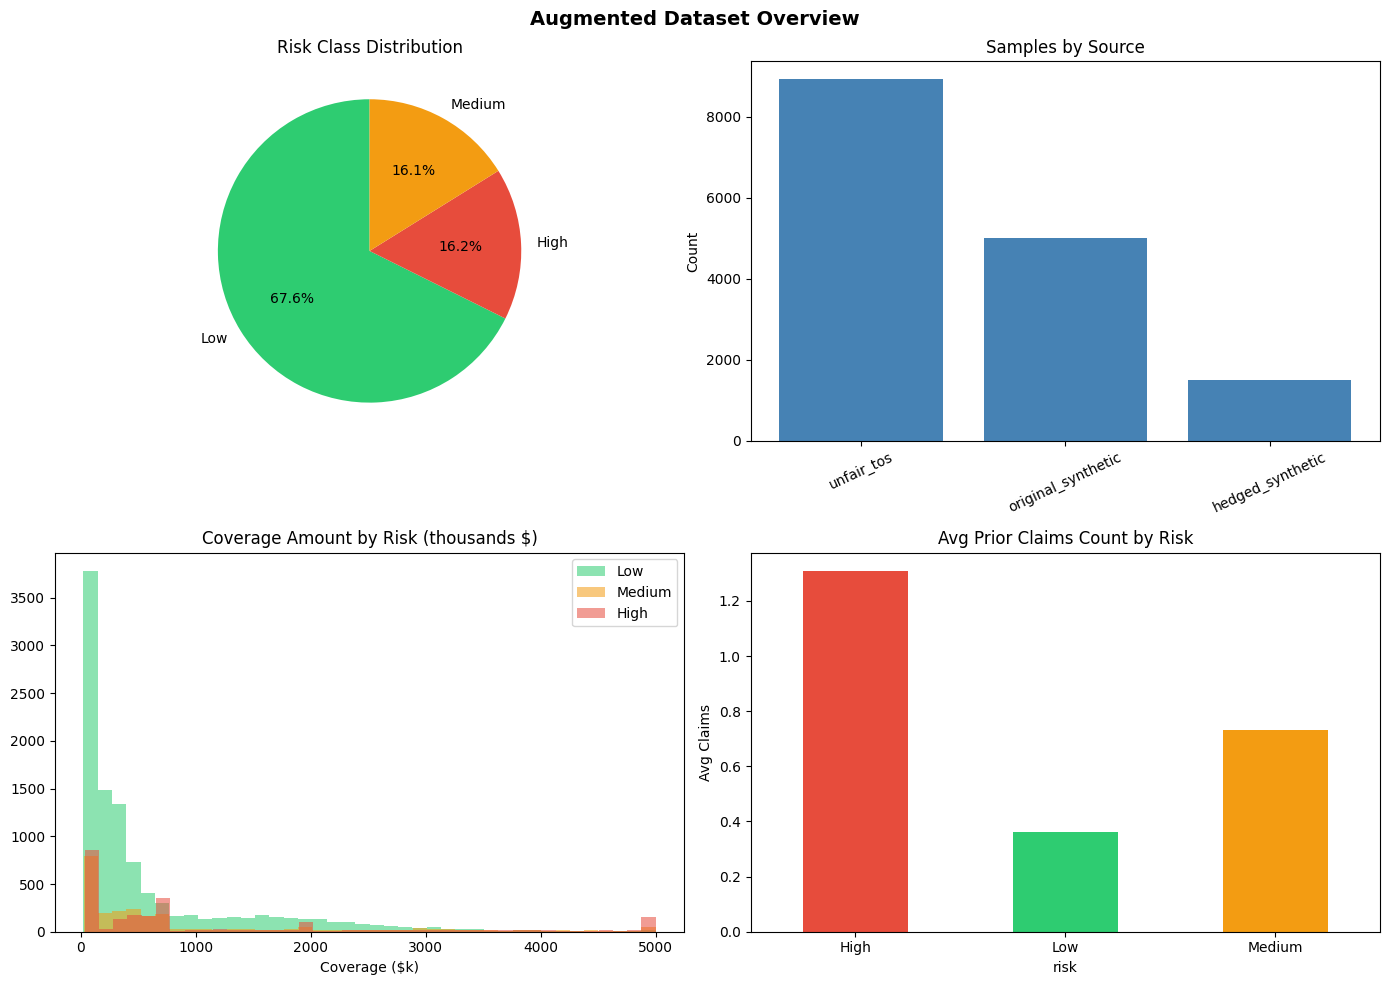

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Augmented Dataset Overview', fontsize=14, fontweight='bold')

# 1 — Risk distribution
risk_counts = df_final['risk'].value_counts()
colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
axes[0, 0].pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    colors=[colors[l] for l in risk_counts.index],
    startangle=90
)
axes[0, 0].set_title('Risk Class Distribution')

# 2 — Samples by source
source_counts = df_final['source'].value_counts()
axes[0, 1].bar(source_counts.index, source_counts.values, color='steelblue')
axes[0, 1].set_title('Samples by Source')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=25)

# 3 — Coverage amount distribution by risk
for risk, color in colors.items():
    subset = df_final[df_final['risk'] == risk]['coverage_amount']
    axes[1, 0].hist(subset / 1000, bins=40, alpha=0.55, label=risk, color=color)
axes[1, 0].set_title('Coverage Amount by Risk (thousands $)')
axes[1, 0].set_xlabel('Coverage ($k)')
axes[1, 0].legend()

# 4 — Prior claims by risk
df_final.groupby('risk')['prior_claims_count'].mean().plot.bar(
    ax=axes[1, 1],
    color=[colors[r] for r in df_final.groupby('risk')['prior_claims_count'].mean().index]
)
axes[1, 1].set_title('Avg Prior Claims Count by Risk')
axes[1, 1].set_ylabel('Avg Claims')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('augmentation_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Export

In [ ]:
out_path = 'augmented_dataset.csv'
df_final.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(f'Rows : {len(df_final):,}')
print(f'Cols : {list(df_final.columns)}')
print()
print('Final class distribution:')
print(df_final['risk'].value_counts())

try:
    from google.colab import files
    files.download(out_path)
except Exception:
    print('\nNot in Colab — file saved locally.')

Saved: augmented_dataset.csv
Rows : 15,425
Cols : ['clause', 'risk', 'source', 'policy_type', 'coverage_amount', 'applicant_age', 'prior_claims_count', 'deductible_amount', 'state']

Final class distribution:
risk
Low       10435
High       2500
Medium     2490
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>